In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [10]:
df.head()
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handle Missing values

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [13]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [48]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [53]:
df.head()
df.isnull().sum()
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'Is loan approved?')

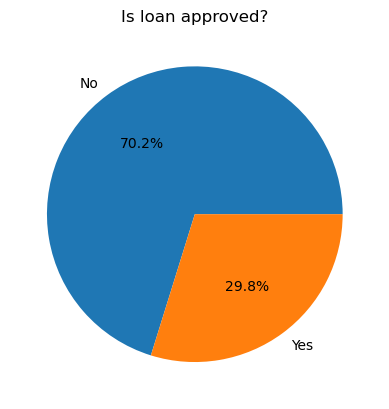

In [27]:
#Balancing

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is loan approved?")

[Text(0, 0, '722'), Text(0, 0, '278')]

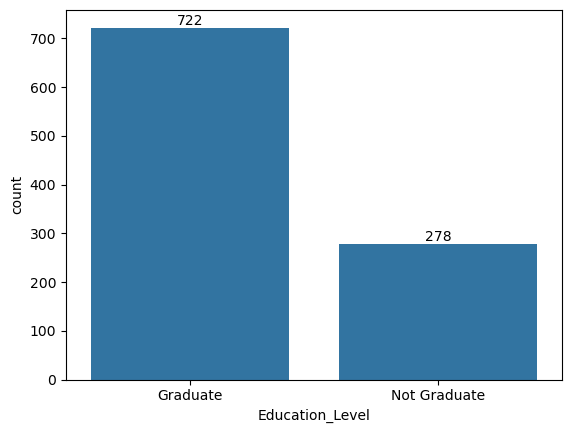

In [34]:
#analyze categories

#gender_cnt = df["Gender"].value_counts()gender_cnt = df["Gender"].value_counts()
#ax = sns.barplot(gender_cnt)
#ax.bar_label(ax.containers[0])

education_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(education_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

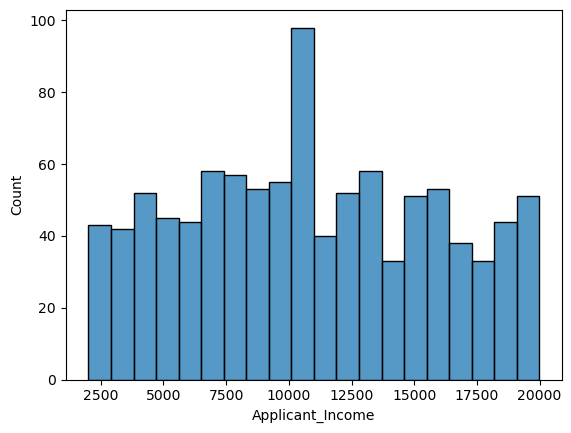

In [37]:
#income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

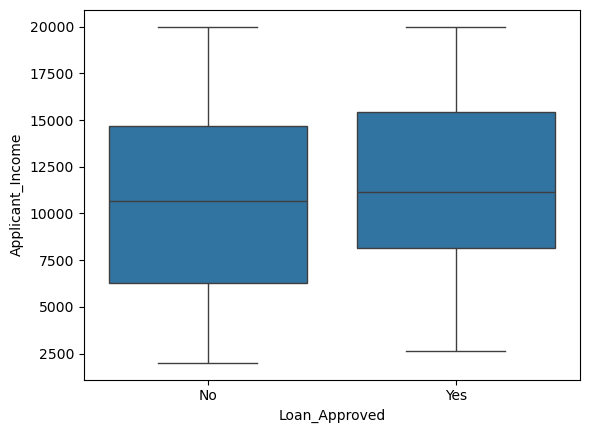

In [38]:
#outliers - boxplots

sns.boxplot(
    data=df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

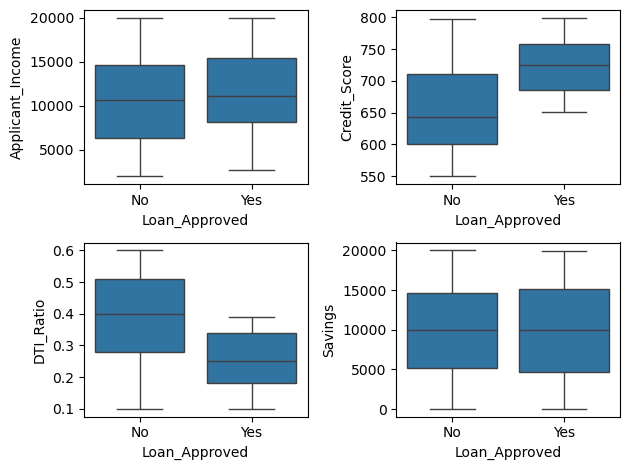

In [43]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data=df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data=df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data=df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1],data=df,x = "Loan_Approved",y = "Savings")

fig.tight_layout()

# Feature Encoding

In [57]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [74]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop = "first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(cols),index = df.index)

df = pd.concat([df.drop(columns = cols),encoded_df],axis=1)

In [75]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

In [80]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [83]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

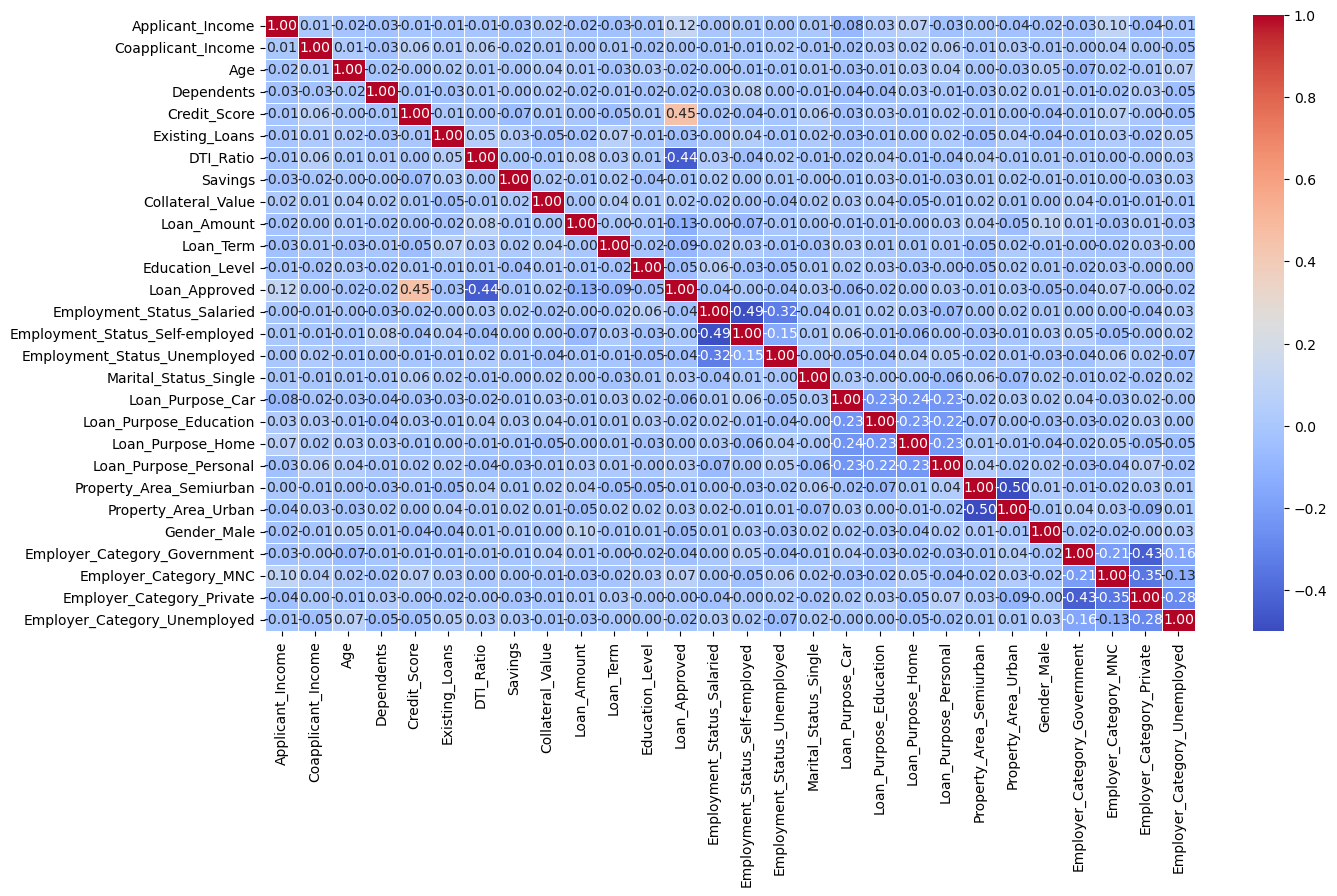

In [88]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    linewidth=0.5
)

# Train-Test Split + Feature Scaling

In [89]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Model

In [94]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [99]:
y_pred = lr_model.predict(X_test_scaled)

#Evaluation
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,accuracy_score
print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1 Score:",f1_score(y_test,y_pred)*100)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("CM:",confusion_matrix(y_test,y_pred)*100)

Precision: 78.33333333333333
Recall: 77.04918032786885
F1 Score: 77.68595041322314
Accuracy: 86.5
CM: [[12600  1300]
 [ 1400  4700]]


In [101]:
#KNN Classifier

from sklearn.neighbors import KNeighborsClassifier
KNN_model = KNeighborsClassifier(n_neighbors=3)
KNN_model.fit(X_train_scaled,y_train)
y_pred = KNN_model.predict(X_test_scaled)

In [102]:
#Evaluation

print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1 Score:",f1_score(y_test,y_pred)*100)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("CM:",confusion_matrix(y_test,y_pred)*100)

Precision: 57.377049180327866
Recall: 57.377049180327866
F1 Score: 57.377049180327866
Accuracy: 74.0
CM: [[11300  2600]
 [ 2600  3500]]


In [103]:
#Naive Bayes

from sklearn.naive_bayes import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)
y_pred = NB_model.predict(X_test_scaled)

In [104]:
#Evaluation

print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1 Score:",f1_score(y_test,y_pred)*100)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("CM:",confusion_matrix(y_test,y_pred)*100)

Precision: 80.35714285714286
Recall: 73.77049180327869
F1 Score: 76.92307692307693
Accuracy: 86.5
CM: [[12800  1100]
 [ 1600  4500]]


# Best Model --->> Naive Bayes

# Feature Engineering

In [113]:
#Add/Transform features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

#df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["Loan_Approved","DTI_Ratio","Credit_Score"])
y = df["Loan_Approved"]

#Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Naive Bayes

NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)
y_pred = NB_model.predict(X_test_scaled)

#Evaluation

print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1 Score:",f1_score(y_test,y_pred)*100)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("CM:",confusion_matrix(y_test,y_pred)*100)

Precision: 81.13207547169812
Recall: 70.49180327868852
F1 Score: 75.43859649122807
Accuracy: 86.0
CM: [[12900  1000]
 [ 1800  4300]]


In [114]:
#Logistic Regression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled,y_train)
y_pred = lr_model.predict(X_test_scaled)

#Evaluation
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,accuracy_score
print("Precision:",precision_score(y_test,y_pred)*100)
print("Recall:",recall_score(y_test,y_pred)*100)
print("F1 Score:",f1_score(y_test,y_pred)*100)
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("CM:",confusion_matrix(y_test,y_pred)*100)

Precision: 78.46153846153847
Recall: 83.60655737704919
F1 Score: 80.95238095238095
Accuracy: 88.0
CM: [[12500  1400]
 [ 1000  5100]]
